# How to reproduce a paper: gamma oscillation

**Task.** Reproduce a published result — the interneuron-network gamma rhythm of
Wang & Buzsáki (1996) — to show how a custom biophysical model is expressed in
`brainpy.state`.

**Audience.** Simulation. Comfortable with custom `Neuron`/`Synapse` subclasses.

Reproducing a paper usually means writing the model's exact equations. This guide
implements the Wang–Buzsáki single-compartment Hodgkin–Huxley interneuron and an
all-to-all GABAergic synapse, drives the network with a constant current, and
recovers the population gamma oscillation. It demonstrates: subclassing
`brainpy.state.Neuron` / `Synapse`, integrating ODEs with `exp_euler_step`, and a
`CurrentProj` with all-to-all connectivity.

Reference: Wang, X-J. & Buzsáki, G. (1996), *Gamma oscillation by synaptic
inhibition in a hippocampal interneuronal network model*, J. Neurosci. 16(20).

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## The Wang–Buzsáki interneuron

A single-compartment model with fast sodium, delayed-rectifier potassium, and a
leak current. We integrate the gating variables and the membrane potential with
the exponential Euler step.

In [2]:
class WBNeuron(brainpy.state.Neuron):
    def __init__(self, in_size, ENa=55. * u.mV, EK=-90. * u.mV, EL=-65. * u.mV,
                 C=1.0 * u.uF, gNa=35. * u.msiemens, gK=9. * u.msiemens,
                 gL=0.1 * u.msiemens, V_th=20. * u.mV, phi=5.0):
        super().__init__(in_size)
        self.ENa, self.EK, self.EL, self.C = ENa, EK, EL, C
        self.gNa, self.gK, self.gL = gNa, gK, gL
        self.V_th, self.phi = V_th, phi

    def init_state(self, *args, **kwargs):
        self.V = brainstate.HiddenState(
            -70. * u.mV + brainstate.random.randn(*self.varshape) * 20. * u.mV)
        self.h = brainstate.HiddenState(
            braintools.init.param(braintools.init.Constant(0.6), self.varshape))
        self.n = brainstate.HiddenState(
            braintools.init.param(braintools.init.Constant(0.3), self.varshape))
        self.spike = brainstate.HiddenState(
            braintools.init.param(lambda s: u.math.zeros(s, dtype=bool), self.varshape))

    def dh(self, h, t, V):
        alpha = 0.07 * u.math.exp(-(V / u.mV + 58) / 20)
        beta = 1 / (u.math.exp(-0.1 * (V / u.mV + 28)) + 1)
        return self.phi * (alpha * (1 - h) - beta * h) / u.ms

    def dn(self, n, t, V):
        alpha = -0.01 * (V / u.mV + 34) / (u.math.exp(-0.1 * (V / u.mV + 34)) - 1)
        beta = 0.125 * u.math.exp(-(V / u.mV + 44) / 80)
        return self.phi * (alpha * (1 - n) - beta * n) / u.ms

    def dV(self, V, t, h, n, Iext):
        m_alpha = -0.1 * (V / u.mV + 35) / (u.math.exp(-0.1 * (V / u.mV + 35)) - 1)
        m_beta = 4 * u.math.exp(-(V / u.mV + 60) / 18)
        m = m_alpha / (m_alpha + m_beta)
        INa = self.gNa * m ** 3 * h * (V - self.ENa)
        IK = self.gK * n ** 4 * (V - self.EK)
        IL = self.gL * (V - self.EL)
        return (-INa - IK - IL + self.sum_current_inputs(Iext, V)) / self.C

    def update(self, x=0. * u.uA):
        t = brainstate.environ.get('t')
        V = brainstate.nn.exp_euler_step(self.dV, self.V.value, t, self.h.value, self.n.value, x)
        h = brainstate.nn.exp_euler_step(self.dh, self.h.value, t, V)
        n = brainstate.nn.exp_euler_step(self.dn, self.n.value, t, V)
        self.spike.value = u.math.logical_and(self.V.value < self.V_th, V >= self.V_th)
        self.V.value, self.h.value, self.n.value = V, h, n
        return self.V.value

## The GABAergic synapse

A first-order kinetic synapse gated by a sigmoid of the presynaptic voltage.

In [3]:
class GABASyn(brainpy.state.Synapse):
    def __init__(self, in_size, alpha=12. / u.ms, beta=0.1 / u.ms):
        super().__init__(in_size=in_size)
        self.alpha, self.beta = alpha, beta

    def init_state(self, *args, **kwargs):
        self.g = brainstate.HiddenState(
            braintools.init.param(braintools.init.ZeroInit(), self.varshape))

    def update(self, pre_V):
        f_v = lambda v: 1 / (1 + u.math.exp(-v / u.mV / 2))
        ds = lambda s: self.alpha * f_v(pre_V) * (1 - s) - self.beta * s
        self.g.value = brainstate.nn.exp_euler_step(ds, self.g.value)
        return self.g.value

## Wire the network

The synapse's conductance `g` is prefetched into a `CurrentProj` with all-to-all
(no self) inhibitory connectivity and a `COBA` output at the chloride reversal
potential.

In [4]:
class GammaNet(brainstate.nn.Module):
    def __init__(self, num=100):
        super().__init__()
        self.neu = WBNeuron(num)
        self.syn = GABASyn(num)
        self.proj = brainpy.state.CurrentProj(
            self.syn.prefetch('g'),
            comm=brainstate.nn.AllToAll(
                self.neu.varshape, self.neu.varshape,
                include_self=False, w_init=0.1 * u.msiemens / num),
            out=brainpy.state.COBA(E=-75. * u.mV),
            post=self.neu)

    def update(self, t, drive):
        with brainstate.environ.context(t=t):
            self.proj()
            self.syn(self.neu(drive))
            return self.neu.spike.value, self.neu.V.value[:5]

## Simulate and visualize

Drive every neuron with a 1 µA current for 500 ms. The raster reveals the
synchronous gamma rhythm produced by mutual inhibition.

  0%|          | 0/50000 [00:00<?, ?it/s]

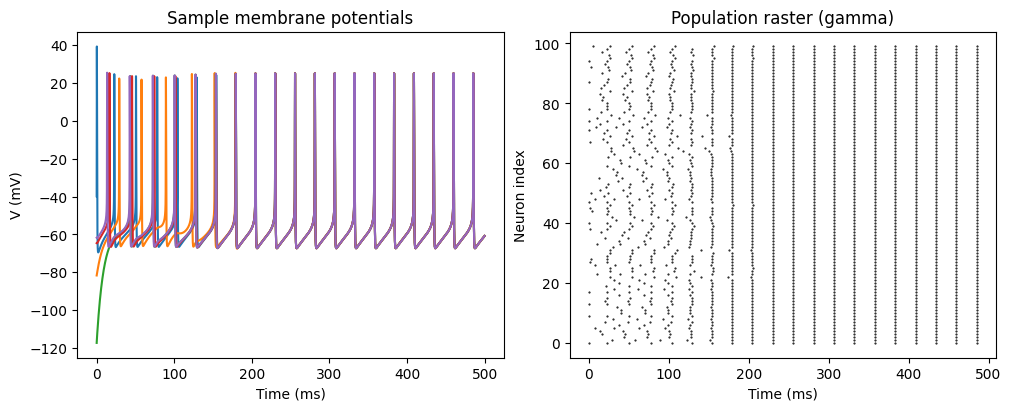

In [5]:
net = GammaNet()
brainstate.nn.init_all_states(net)

with brainstate.environ.context(dt=0.01 * u.ms):
    times = u.math.arange(0. * u.ms, 500. * u.ms, brainstate.environ.get_dt())
    spikes, vs = brainstate.transform.for_loop(
        lambda t: net.update(t, 1.0 * u.uA), times,
        pbar=brainstate.transform.ProgressBar(10))

fig, gs = braintools.visualize.get_figure(1, 2, 4.0, 5.0)
fig.add_subplot(gs[0, 0])
plt.plot(times.to_decimal(u.ms), vs.to_decimal(u.mV))
plt.xlabel('Time (ms)'); plt.ylabel('V (mV)'); plt.title('Sample membrane potentials')
fig.add_subplot(gs[0, 1])
ti, ni = u.math.where(spikes)
plt.plot(times[ti].to_decimal(u.ms), ni, 'k.', markersize=1)
plt.xlabel('Time (ms)'); plt.ylabel('Neuron index'); plt.title('Population raster (gamma)')
plt.show()

## See also

- :doc:`/concepts/model-anatomy` — the `Neuron`/`Synapse` base classes you
  subclassed here.
- :doc:`../tutorials/03-ei-balanced-network` — a network from built-in models.
- :doc:`/examples/brainpy-gallery` — more reproductions and complete scripts.